# <font color='blue'>Volatility and Regimes</font>
<div class="alert alert-block alert-info">
<b>Abstract:</b><br> <p>This study we develop a framework to address two essential question is stock market. (Five possible regimes are considered) 1) Was some of the rare fluctuation occurs in stock market cause by the result of changing the regiem? 2) What driving forces are behind the market changing from one regime to another one? In this case study we use <em>genetic algorithm </em>and <em>derivative-free optimization GA solver </em>to analyzing the monthly CBOE volatility index(VIX) from January 1990 to December 2019(360 months duration), find out that the <b><em>rare fluctuation in stock market is potentially cause by changing regime.</b></em> Then we use OLS, LASSO, Ridge Regression and Elastic Net Regression to analysis the monthly value of MEMV and all  categories of monthly EMV tracker from January 1990 - December 2025, find out the value of VIX is related to 'overall EMV tracker', which means <b><em>'overalll EMV tracker' forces driving the market volatility. </em></b> </p>
</div>

# Introduction
<div class="alert alert-block alert-warning">
<b>Background</b><br><p>  The CBOE volatility index was created by Chicago Board Options Exchange known as CBOE, and this index is a real time index which represents the market’s expectations for the relative strength of near-term price changes of the S&P 500 index (SPX), and it is maintained by Cboe Global Markets(Cite!!!!!). For the absloute value of VIX, if it is smaller than <b>20</b> means the stock market is generally stable unlikely to have large volatility, but if VIX is greater than <b>30</b> means increasing of uncertainty and risk. Equity Market Volatility(EMV) tracker is move with CBOC VIX and the he realized volatility of returns on the S&P 500.EMV is constructed by the monthly articles which from 10 leading U.S newspaper. VIX also can generates a 30 days forward projection of volatility in stock market, which means for most fluctuations are predictable by using VIX. But for some rare fluctuation it is hard to predicted by VIX, so finding the reson which cause rare fluctuation is very improtant for investment. In this case study our predictions is most of rare fluctuation is caused by regime-switching phenomenon and VIX is related to MEMV</p><p><br>In this investigation we trying to solve some important question regarding to stock market. 1)How to forecast the stock market fear index 2)how to construct a predictive model to forecast the direction of stock market's future movment. 3) How expected VIX related to MEMV. </p><br><b>Data and Variable Definition</b><br><p>The collection of data are consists of monthly data from January 1990 to December 2019 and corresponding VIX creat by the CBOE and also the monthly category-specific EMV uncertainty indexes. <br>Variable: In order to use derivative-free optimization GA solver, we first need to find the MoG pdf for each regime. <br> <center><h4>$f_{X_t}(x_t; \theta) = \sum\limits_{i=1}^{k}\pi_i(\frac{1}{\sqrt{2\pi}\sigma_i}) exp ( -\frac{(x_t-\mu_i)^2}{2\sigma_i^2} )$</h4></center><br>From the above equation we can find out the MoG pdf. In this formular k means the number of regimes and $\pi_i$ is the probability of each regime. $X_t$ is the monthly log_returns of VIX, formular shown as:<br><center><h4>$X_t = log\frac{VIX_t}{VIX_{t-1}}$</h4></center><br>$VIX_t$ is the VIX of this month and smiliarly $VIX_{t-1}$ means VIX for last month.<br>  The value of $\theta$: $$\begin{bmatrix} \theta_1 \\ \theta_2 \\ . \\ . \\ . \\ \theta_k\end{bmatrix} = \begin{bmatrix} \mu_1 & \sigma_1 & \pi_1 \\ \mu_2 & \sigma_2 & \pi_2 \\ . & . & . \\ . & . & . \\ . & . & . \\ \mu_k & \sigma_k & \pi_k \end{bmatrix}$$ <br>We aim to maximize the log-likelihood function by solving the following constrained optimization problem. <br> <center><h4>min $l(\theta) = -2n\sum\limits_{j=1}^{m}\hat{p_j}log(\frac{p_j(\theta)}{\hat{p_j}})$</h4></center><br> s.t <center><h4>$\sum\limits_{i=1}^{k} = 1$</h4></center><br> <center><h4>$\pi_i\in [0, 1]$</h4></center><br><center><h4>$\mu_i\in[\infty, -\infty]$</h4></center><br><center><h4>$\sigma_i\in[0, \infty]$</h4></center><br> where i = 0,1,2...k, and $p_j(\theta)$ is: <br> <center><h4>$p_j(\theta) = \int\limits_{b_j}^{b_{j+s}} \sum\limits_{i=1}^{k} \pi_i(\frac{1}{\sqrt{2\pi}\theta_i}) exp ( -\frac{(x_t-\mu_i)^2}{2\sigma_i^2} ) dx_t$ </h4></center><br>To find the dominate regime of $X_t$ in given month t, we ues: <br> <center><h4>$max_i(P(S_t = i)| x_t; \theta)$</h4></center><br> Where, <center><h4>$P(S_t | x_t; \theta) = \frac{f_i(x_t; \theta_i)}{f(x_t; \theta)}$</h4></center><br> The above formular return the probability that $X_t$ is dominated by regime i, and the regime which have the maximum probability is the most likely regime for $X_t$. </p>
</div>

# Model Specification
<div class="alert alert-block alert-warning">
<p>The given MVIX is a complicate data, and it might have multipe local minimum points. Also the problem of find the expected VIX in nonlinear, so in this case study we use genetic algorithm and derivative-free optimization GA solver to find the predictive model to forecast the stock mark movement. The objective function is: <br> <center><h4>min $l(\theta) = -2n\sum\limits_{j=1}^{m}\hat{p_j}log(\frac{p_j(\theta)}{\hat{p_j}})$</h4></center><br> and the constrains are, <center><h4>$\sum\limits_{i=1}^{k} = 1$</h4></center><br> <center><h4>$\pi_i\in [0, 1]$</h4></center><br><center><h4>$\mu_i\in[\infty, -\infty]$</h4></center><br><center><h4>$\sigma_i\in[0, \infty]$</h4></center><br> where i = 0,1,2...k<br> There have four condidates(OLS, LASSO, Ridge Regression and Elastic Net Regression) regression model to analysis the relationship between VIX and MEMV. This study will compare their performances by providing a thorough interpretation of their results, then discuss the advantages and drawbacks of each method. </p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import _pickle as pickle
from genetic_algorithm import GeneticAlgorithm as ga
from scipy.stats import norm, chi2
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

Helper function load_pickle_dataset used to load pkl data

In [2]:
# Support MEMV, MEPU, MVIX
#for dataset in ['MEMV', 'MEPU', 'MVIX']:
vix_file = "MVIX"

#dataset_path = f"./pkl/{dataset}.csv"               # VIX data from 1990-2019
#dataset_path = f"./data/processed/{vix_file}.csv"   # VIX data from 1990-2025
dataset_path = f"./output/temp/data/processed/{vix_file}.csv"   # VIX data from 1990-2025

emv_file = "MEMV"
#dataset_path = f"./pkl/{dataset}.pkl"
#emvdatasfile_path = f"./pkl/{emv_file}.csv"         # VIX data from 1990-2019
#emvdatasfile_path = f"./data/processed/{emv_file}.csv"         # VIX data from 1990-2025
emvdatasfile_path = f"./output/temp/data/processed/{emv_file}.csv"         # VIX data from 1990-2025

#result_filename ="result_para.pkl"  # that used for VIX data from 1990-2019
result_filename ="result_para_v2.pkl"   # that used for VIX data from 1990-2025

num_bins = 48
kbound = 6




In [3]:
def load_dataset(file_path):
    """ This function loads a csv file given a file path.

    Args:
    - file_path (str): The path of the csv file

    Output:
    - (dict): A dictionary consisting the dataset content.
    """

    df = pd.read_csv(file_path)

    # 如果存在 DATE 或 DATA 列，则将其设置为 index
    if "DATE" in df.columns:
        df["DATE"] = pd.to_datetime(
            df["DATE"],
            format="%m/%d/%Y"
        )
        df = df.set_index("DATE")

    elif "DATA" in df.columns:
        df["DATA"] = pd.to_datetime(
            df["DATA"],
            format="%m/%d/%Y"
        )
        df = df.set_index("DATA")

    df.columns = df.columns.str.strip()

    return df

Function to create object function. The object function is embedding in get_objfun

Function to train GA model. The parameters of GA model is saved in result_para.pkl file

In [4]:
def train_model():

    data = load_dataset(dataset_path)
    np_data = data.to_numpy()

    #print(np_data)
    #data.plot()

    Xt = np.log(np_data[1:np_data.shape[0],] / np_data[0:np_data.shape[0] - 1,])

    data_mean = np.mean(Xt)
    data_std = np.std(Xt)

    # --- Bounds for Means (mu) ---
    mu_lower = data_mean - 3.0 * data_std
    mu_upper = data_mean + 3.0 * data_std

    # --- Bounds for Standard Deviations (sigma) ---
    sigma_lower = max(1e-4, 0.05 * data_std)
    sigma_upper = 3.5 * data_std
    
    result_paras = np.empty((kbound - 1, 2), dtype=object)
    for num_classes in range(1, kbound):
        obj_fun = get_objfun(Xt, num_classes, num_bins)
        varbound = np.empty((3*num_classes + 1, 2))
        
        for i in range(0, num_classes):
            # bound for means
            varbound[i] = np.array([mu_lower, mu_upper])
            # bound for stand variance
            varbound[num_classes + i] = np.array([sigma_lower, sigma_upper])
            # bound for pi
            varbound[2*num_classes + i] = np.array([0,1])
            
        varbound[3*num_classes]=np.array([9000.0, 9999.0])
    
        algorithm_param = {'max_num_iteration': 2000,\
                       'population_size':100,\
                       'mutation_probability':0.1,\
                       'elit_ratio': 0.01,\
                       'crossover_probability': 0.5,\
                       'parents_portion': 0.3,\
                       'crossover_type':'uniform',\
                       'max_iteration_without_improv':None}
    
        model = ga(function=obj_fun, dimension=3*num_classes + 1,\
                  variable_type='real',\
                  variable_boundaries=varbound,
                 algorithm_parameters=algorithm_param)
    
        model.run()
        result_paras[num_classes - 1] = np.array([num_classes, model.best_variable], dtype=object)
        
    # result_filename ="result_para.plk"
    result_f = open(result_filename, 'wb')
    np.save(result_f, result_paras)
    
    result_f.close()

In [5]:
def get_objfun(Xt, classes, bins_num):

    K = classes
    M = bins_num

    phat, bins = np.histogram(Xt, M)
    #plt.show()
    phat = phat/len(Xt)
    assert (phat.shape[0] == M),-f"number of phats should be {M}, current is {phat.shape[0]}"
    assert (bins.shape[0] == M + 1),-f"number of bins edget should be {M+1}, current is {bins.shape[0]}"


    def object_fun(input_X, object_value=True):
        assert input_X.shape[0] == 3 * K + 1, f"Param dimension should be {3 * K + 1}, current is {input_X.shape[0]}"

        # 1. Unpack parameters (fully vectorized)
        mus = input_X[:K]  # Shape: (K,)
        sigmas = input_X[K:2 * K]  # Shape: (K,)
        pis = input_X[2 * K:3 * K]  # Shape: (K,)
        penalty_weight = input_X[3 * K]

        # 2. Compute CDF differences across all regimes and bins using broadcasting
        # bins: (M+1,) -> bins[1:] and bins[:-1] have shape (M, 1)
        # mus, sigmas have shape (1, K)
        # Standardize boundary values z = (x - mu) / sigma
        z_upper = (bins[1:, np.newaxis] - mus[np.newaxis, :]) / sigmas[np.newaxis, :]
        z_lower = (bins[:-1, np.newaxis] - mus[np.newaxis, :]) / sigmas[np.newaxis, :]

        # cdf_diffs shape: (M, K), representing the probability measure of bin i under component j
        cdf_diffs = norm.cdf(z_upper) - norm.cdf(z_lower)

        # 3. Matrix multiplication to compute theoretical bin probabilities: li = sum_j (pi_j * P_ij)
        # li_array shape: (M,)
        li_array = cdf_diffs @ pis

        # 4. Vectorized calculation for cross-entropy / log-likelihood terms (only where phat > 0)
        valid_mask = phat > 0
        phat_v = phat[valid_mask]
        li_v = li_array[valid_mask]

        # Clip values to prevent numerical instability or log(0) errors
        eps = 1e-15
        li_v = np.maximum(li_v, eps)

        # Vectorized objective component: sum( phat * log(li / phat) )
        obj_value = np.sum(phat_v * np.log(li_v / phat_v))

        # 5. Apply scaling factor and constraint penalty
        obj_value = (-2.0) * len(Xt) * obj_value

        if object_value:
            # Add L1 penalty term for sum(pi) != 1 constraint
            obj_value += penalty_weight * np.abs(np.sum(pis) - 1.0)
        else:
            # Compute total Log-Likelihood
            C_empirical = np.sum(phat_v * np.log(phat_v))
            obj_value = len(Xt) * C_empirical - 0.5 * obj_value

        return obj_value

    return object_fun

In [6]:
def get_samples(input_params, dimensions, bins):
    assert (input_params.shape[0] == 3*dimensions + 1),-f"param dimension should be {3*dimensions + 1}, current is {input_params.shape[0]}"  
    
    norm_funs = np.empty((dimensions,), dtype=object)
    pis = np.empty((dimensions,))
    
    for i in range(0, dimensions):
        norm_funs[i] = norm(loc=input_params[i], scale=input_params[dimensions + i])
        pis[i] = input_params[2*dimensions + i]
        
    samples = np.zeros((len(bins),))
    
    for i in range(0, len(bins)):
        for j in range(0, dimensions):
            samples[i] += pis[j] * (norm_funs[j].pdf(bins[i]))
    
    return samples

In [7]:
# train the model of GA solver
#train_model()

f = open(result_filename, 'rb')
    
param_result = np.load(f, allow_pickle=True)
    
f.close()

data = load_dataset(dataset_path)

np_data = data.to_numpy()

#print(np_data)

#data.plot()

Xt = np.log(np_data[1:np_data.shape[0],] / np_data[0:np_data.shape[0] - 1,])
N_return = len(Xt)

print("The mean and std of data set is mean = {:.6f}, std = {:0.6f}".format(np.mean(Xt), np.std(Xt)))
    
#print(param_result)
# print parameter for models of different regimes
pvalue_tab = np.empty((param_result.shape[0], 2))
    
for i in range(0, param_result.shape[0]):
    classes = param_result[i,0]
    params = param_result[i,1]
    params[3*classes] = 0

    # Post-normalization pi, make sure sum of pi equal to 1
    # start index of pi
    pi_start_idx = 2 * classes

    # end index of pi
    pi_end_idx = 3 * classes

    # slic of pi
    pi_sum = np.sum(params[pi_start_idx:pi_end_idx])
    params[pi_start_idx:pi_end_idx] = params[pi_start_idx:pi_end_idx] / pi_sum
        
    obj_fun = get_objfun(Xt, classes, num_bins)
        
        
    final_value = obj_fun(params)

    #The model parameters consist of k means, k standard deviations, and k-1 independent mixture weights , yielding 3k-1 estimated independent parameters
    k_params = 3 * classes - 1
    deg_freedom = num_bins - k_params - 1
    p_value = 1-chi2.cdf(final_value, deg_freedom)
    pvalue_tab[i] = np.array([classes, p_value])
        
    df = pd.DataFrame(params[0: 3*classes].reshape(3, classes).T, columns = ['means','standard var','Pi'])

    log_likelihood = obj_fun(params, False)

    aic = 2 * k_params - 2 * log_likelihood
    bic = k_params * np.log(N_return) - 2 * log_likelihood

    print("Model parameters of {} regimes".format(classes))
    print(df)

    print("X square stat: {:.6f}".format(final_value))
    print("Degrees of freedom : {}".format(deg_freedom))
    print("P value: {:.6f}".format(p_value))
    print('Log-Likelihood: {:.4f}'.format(log_likelihood))
    print('AIC: {:.4f}'.format(aic))
    print('BIC: {:.4f}'.format(bic))

    print("\n")      



The mean and std of data set is mean = -0.001226, std = 0.198890
Model parameters of 1 regimes
      means  standard var   Pi
0 -0.001006      0.198562  1.0
X square stat: 77.260946
Degrees of freedom : 45
P value: 0.001962
Log-Likelihood: -1418.5709
AIC: 2841.1418
BIC: 2849.2741


Model parameters of 2 regimes
      means  standard var        Pi
0 -0.039393      0.109942  0.393929
1  0.024090      0.236183  0.606071
X square stat: 58.781780
Degrees of freedom : 42
P value: 0.044329
Log-Likelihood: -1409.3313
AIC: 2828.6627
BIC: 2848.9932


Model parameters of 3 regimes
      means  standard var        Pi
0  0.019400      0.231202  0.407340
1  0.159822      0.303579  0.063822
2 -0.034735      0.130308  0.528838
X square stat: 58.465359
Degrees of freedom : 39
P value: 0.023298
Log-Likelihood: -1409.1731
AIC: 2834.3463
BIC: 2866.8751


Model parameters of 4 regimes
      means  standard var        Pi
0  0.270780      0.278884  0.034587
1 -0.091826      0.165049  0.423994
2  0.006002    

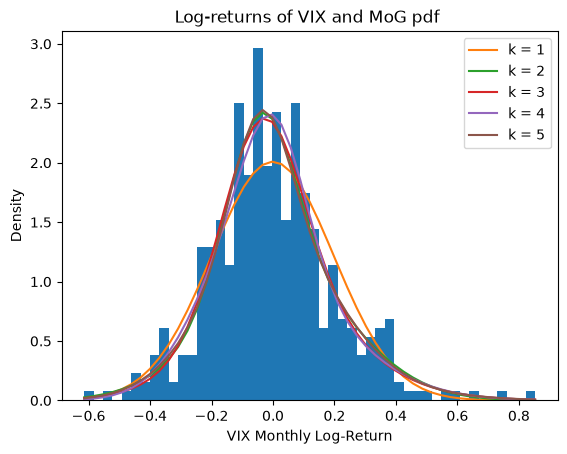

In [8]:
# visalize MoG pdf and Log-return of VIX data
temp_data = load_dataset(dataset_path)
temp_data = temp_data.to_numpy()            
temp_data = np.log(temp_data[1:temp_data.shape[0],] / temp_data[0:temp_data.shape[0] - 1,])
    
plt.xlabel('VIX Monthly Log-Return')
plt.ylabel('Density')
plt.title('Log-returns of VIX and MoG pdf ')
_, bins_edge, _ = plt.hist(temp_data, num_bins, density=True)  
for i in range(0, len(param_result)):
    y_mog = get_samples(param_result[i,1], param_result[i,0], bins_edge)
    plt.plot(bins_edge, y_mog, label=f'k = {param_result[i,0]}')
        
plt.legend()
plt.savefig('Log-returns_and_MoG_pdf.pdf', format='pdf', bbox_inches='tight')
plt.show()
    
# Compare p-values of different regimes
#df = pd.DataFrame(pvalue_tab, columns = ['regimes','p-value'])
#print(df)



2 regimes for GA model is suitable

In [9]:
# compute MCP of VIX, Using 2 regimes MoG model
regimes_index = 1  
regimes_number = param_result[regimes_index,0]
pb_matrix = np.zeros((temp_data.shape[0], regimes_number))    
for i in range(0, regimes_number):
    temp_u = param_result[regimes_index,1][i]
    temp_q = param_result[regimes_index,1][regimes_number + i]
    temp_pi = param_result[regimes_index,1][2*regimes_number + i ]
    pb_matrix[:,i] = temp_pi * \
        np.exp(-(np.square(temp_data[:,0] - temp_u)/(2*temp_q*temp_q)))/ \
        (np.sqrt(2*np.pi)*temp_q)
        
#pb_matrix = pb_matrix/np.sum(pb_matrix, axis=1).reshape(pb_matrix.shape[0], 1)
pb_matrix = pb_matrix/np.sum(pb_matrix, axis=1, keepdims=True)
mcp = np.zeros((pb_matrix.shape[0], 2))
mcp[:,0] = np.max(pb_matrix, axis=1)
mcp[:,1] = np.argmax(pb_matrix, axis=1)
df = pd.DataFrame(mcp, columns = ['mcp','regimes'])
print(df)
    
# plot Xt and regimes info
#plt.plot(temp_data)
#plt.plot(mcp[:,1])
#plt.show()
    

          mcp  regimes
0    0.535526      0.0
1    0.572981      0.0
2    0.577038      0.0
3    0.565693      0.0
4    0.568283      0.0
..        ...      ...
426  0.587769      0.0
427  0.512374      1.0
428  0.533128      1.0
429  0.593410      0.0
430  0.585547      0.0

[431 rows x 2 columns]


In [10]:
# K*K transition Matrix
trans_matrix = np.zeros((2,2))
month_regimes = mcp[:,1]
regimes_chg = month_regimes[1:mcp.shape[0]] - month_regimes[0:mcp.shape[0]-1]
trans_matrix[0,1] = np.sum(regimes_chg==1)
trans_matrix[1,0] = np.sum(regimes_chg==-1)
temp_index = np.argwhere(regimes_chg==0)
trans_matrix[0,0] = np.sum(month_regimes[temp_index]==0)
trans_matrix[1,1] = np.sum(month_regimes[temp_index]==1)
trans_matrix = trans_matrix/np.sum(trans_matrix)
print("K*K transition matrix for 2 regims is:\n", trans_matrix)
print("\n")

K*K transition matrix for 2 regims is:
 [[0.19767442 0.24883721]
 [0.24883721 0.30465116]]




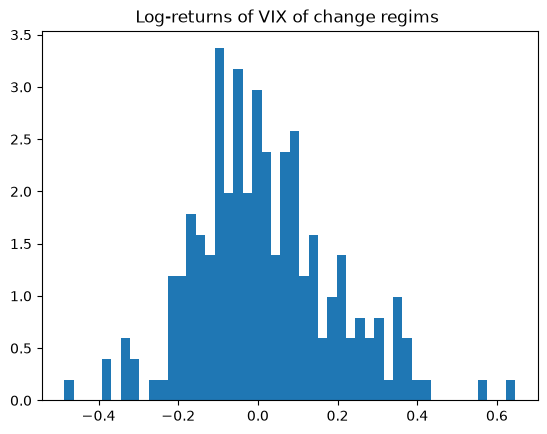

In [11]:
temp_index = np.argwhere(regimes_chg!=0) + 1
temp_change = temp_data[temp_index].flatten()
# plot Xt and regimes info
plt.title('Log-returns of VIX of change regims ')
plt.hist(temp_change, num_bins, density=True)   
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV


temp_MEMV_tf = load_dataset(emvdatasfile_path)
temp_MEMV = temp_MEMV_tf.to_numpy()
temp_MEMV = temp_MEMV[0:temp_MEMV.shape[0] - 1,]  

# dataset = "MVIX"
# #dataset_path = f"./pkl/{dataset}.pkl"
# dataset_path = f"./pkl/{dataset}.csv"
temp_MVIX = load_dataset(dataset_path)
temp_MVIX = temp_MVIX.to_numpy() 
temp_MVIX = np.log(temp_MVIX[1:temp_MVIX.shape[0],] / temp_MVIX[0:temp_MVIX.shape[0] - 1,])


# # Using OLS
# reg = linear_model.LinearRegression()
# reg.fit(temp_MEMV, temp_MVIX)
# # The coefficients
# #print("Coefficients: \n", reg.coef_)
# y_pred = reg.predict(temp_MEMV)
# # The mean squared error
# print("Using OLS training mean squared error: %.5f" % mean_squared_error(temp_MVIX, y_pred))
# # The coefficient of determination: 1 is perfect prediction
# #print("Coefficient of determination: %.2f" % r2_score(diabetes_y_test, diabetes_y_pred))
# print("Effective feature number: %d\n" %  np.count_nonzero(reg.coef_))
#
# # Using Ridge Regression
# reg = linear_model.Ridge(alpha=0.1)
# reg.fit(temp_MEMV, temp_MVIX)
# # The coefficients
# #print("Coefficients: \n", reg.coef_)
# y_pred = reg.predict(temp_MEMV)
# # The mean squared error
# print("Using Ridge Regression training mean squared error: %.5f" % mean_squared_error(temp_MVIX, y_pred))
# print("Effective feature number: %d\n" %  np.count_nonzero(reg.coef_))
#
# # Using LASSO
# reg_lasso = linear_model.LassoCV(alphas=np.logspace(-4, 1, 100))
# #reg_lasso = linear_model.Lasso(alpha=0.0187)
# reg_lasso.fit(temp_MEMV, temp_MVIX)
# # The coefficients
# #print("Coefficients: \n", reg.coef_)
# y_pred_lasso = reg_lasso.predict(temp_MEMV)
# # The mean squared error
# print(f"LASSO (Best Alpha={reg_lasso.alpha_:.4f}) Training MSE: {mean_squared_error(temp_MVIX, y_pred_lasso):.5f}")
# #print(f"LASSO Training MSE: {mean_squared_error(temp_MVIX, y_pred_lasso):.5f}")
# print("Effective feature number: %d" %  np.count_nonzero(reg_lasso.coef_))
# print(f"LASSO Net Non-Zero Feature Indices: {np.where(reg_lasso.coef_ != 0)[0]}\n")
#
# # Using Elastic Net Regression
# reg = linear_model.ElasticNet(alpha=0.1, l1_ratio=0.7)
# reg.fit(temp_MEMV, temp_MVIX)
# # The coefficients
# print("Coefficients: \n", reg.coef_)
# y_pred = reg.predict(temp_MEMV)
# # The mean squared error
# print("Using Elastic Net Regression training mean squared error: %.5f" % mean_squared_error(temp_MVIX, y_pred))
# print("Effective feature number: %d" %  np.count_nonzero(reg.coef_))
# print(f"Elastic Net Non-Zero Feature Indices: {np.where(reg.coef_ != 0)[0]}\n")

# Flatten the target dimension to fit sklearn (N, 1) -> (N,)
temp_MVIX_ravel = temp_MVIX.ravel()

# 2. Standard Scaling for Regularized Regressions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(temp_MEMV)

# 3. Set up 10-fold cross-validation (K-Fold CV)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("=== Empirical Regression Results (Full Sample: 1990-2025) ===\n")

# --- OLS ---
reg_ols = linear_model.LinearRegression()
reg_ols.fit(X_scaled, temp_MVIX_ravel)
y_pred_ols = reg_ols.predict(X_scaled)
print(f"OLS Training MSE: {mean_squared_error(temp_MVIX_ravel, y_pred_ols):.5f}")
print(f"OLS Effective Features: {np.count_nonzero(reg_ols.coef_)}\n")

# --- Ridge ---
reg_ridge = linear_model.RidgeCV(alphas=np.logspace(-3, 3, 100), cv=kf)
reg_ridge.fit(X_scaled, temp_MVIX_ravel)
y_pred_ridge = reg_ridge.predict(X_scaled)
print(f"Ridge (Best Alpha={reg_ridge.alpha_:.4f}) Training MSE: {mean_squared_error(temp_MVIX_ravel, y_pred_ridge):.5f}")
print(f"Ridge Effective Features: {np.count_nonzero(reg_ridge.coef_)}\n")

# --- LASSO ---
reg_lasso = linear_model.LassoCV(alphas=np.logspace(-4, 1, 100), cv=kf, max_iter=10000, random_state=42)
reg_lasso.fit(X_scaled, temp_MVIX_ravel)
y_pred_lasso = reg_lasso.predict(X_scaled)
lasso_active = np.count_nonzero(reg_lasso.coef_)
print(f"LASSO (Best Alpha={reg_lasso.alpha_:.4f}) Training MSE: {mean_squared_error(temp_MVIX_ravel, y_pred_lasso):.5f}")
print(f"LASSO Effective Features: {lasso_active}")
print(f"LASSO Non-Zero Feature Indices: {np.where(reg_lasso.coef_ != 0)[0]}")
print(f"LASSO Non-Zero Feature is: {temp_MEMV_tf.columns[np.where(reg_lasso.coef_ != 0)[0]]}\n")

# --- Elastic Net ---
elastic_grid = {
    'alpha': np.logspace(-4, 1, 50),
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
reg_enet = GridSearchCV(linear_model.ElasticNet(max_iter=10000, random_state=42),
                        elastic_grid, cv=kf, scoring='neg_mean_squared_error')
reg_enet.fit(X_scaled, temp_MVIX_ravel)
best_enet = reg_enet.best_estimator_
y_pred_enet = best_enet.predict(X_scaled)
enet_active = np.count_nonzero(best_enet.coef_)
print(f"Elastic Net Best Params: {reg_enet.best_params_}")
print(f"Elastic Net Training MSE: {mean_squared_error(temp_MVIX_ravel, y_pred_enet):.5f}")
print(f"Elastic Net Effective Features: {enet_active}")
print(f"Elastic Net Non-Zero Feature Indices: {np.where(best_coefs := best_enet.coef_ != 0)[0]}")
print(f"Elastic Net Non-Zero Feature is: {temp_MEMV_tf.columns[np.where(best_enet.coef_ != 0)[0]]}")

=== Empirical Regression Results (Full Sample: 1990-2025) ===

OLS Training MSE: 0.03453
OLS Effective Features: 43

Ridge (Best Alpha=1000.0000) Training MSE: 0.03754
Ridge Effective Features: 43

LASSO (Best Alpha=0.0187) Training MSE: 0.03853
LASSO Effective Features: 3
LASSO Non-Zero Feature Indices: [3 5 7]
LASSO Non-Zero Feature is: Index(['Macro – Broad Quantity Indicators EMV Tracker',
       'Macro – Interest Rates EMV Tracker',
       'Macro – Labor Markets EMV Tracker'],
      dtype='object')

Elastic Net Best Params: {'alpha': np.float64(0.14563484775012445), 'l1_ratio': 0.1}
Elastic Net Training MSE: 0.03832
Elastic Net Effective Features: 4
Elastic Net Non-Zero Feature Indices: [ 3  5  7 31]
Elastic Net Non-Zero Feature is: Index(['Macro – Broad Quantity Indicators EMV Tracker',
       'Macro – Interest Rates EMV Tracker',
       'Macro – Labor Markets EMV Tracker',
       'Energy and Environmental Regulation EMV Tracker'],
      dtype='object')
